# Assignment #1. Spectral approximations and operations.
In this assignment, you will develop fundamental routines for a spectral methods toolbox in
Python/Matlab/Julia that will be useful for later solving differential equations. A partial goal
is to develop your ability to perform ’computational thinking’ through mastering fundamental
concepts and linking theory to practical implementations to be able to explain gaps.
## Fourier Spectral Methods (Estimated effort: 2 weeks)
### subpart a)

We start by defining the target function $u(x)$ on the domain $x \in [0, 2]$.

In [1]:
import numpy as np

u = lambda x: 1 / (2 - np.cos(x * np.pi))

To find the exact continuous Fourier coefficients $\hat{u}_k$, we evaluate the standard integral:
$$
    \hat{u}_k = \frac{1}{2} \int_{0}^{2} u(x) e^{-i k \pi x} dx
$$
where we use the substitution $\theta = \pi x$ mapping our domain to a standard unit circle $[0, 2\pi]$. The integral is then;
$$
    \hat{u}_k = \frac{1}{2\pi} \int_{0}^{2\pi} \frac{e^{-i k \theta}}{2-\cos(\theta)} d\theta
$$
We substitute $z = e^{i\theta}$ because we remember that Euler's formula is
$$
    e^{i\theta} = \cos(\theta) + i \sin(\theta)
$$
or for a negative angle $-\theta$
$$
    e^{-i\theta} = \cos(\theta) - i \sin(\theta)
$$
we can use this to find an expression for $\cos(\theta)$
\begin{align*}
    e^{i\theta} + e^{-i\theta} &= 2\cos(\theta) \\
    \cos(\theta) &= \frac{e^{i\theta} + e^{-i\theta}}{2} = \frac{z + z^{-1}}{2}
\end{align*}
we also want to convert $d\theta$ into $dz$. The derivative of $z$ wrt $\theta$ is $z' = \frac{dz}{d\theta} = (e^{i\theta})' = ie^{i\theta}$. We can rearrange it as
$$
    dz = ie^{i\theta}d\theta
$$
or
$$
    d\theta = \frac{dz}{ie^{i\theta}}
$$
and since $z = e^{i\theta}$, we instead say; $d\theta = \frac{dz}{iz}$. \
We substitute this back into our expression for $\hat{u}_k$, replacing $e^{-ik\theta}$ with $z^{-k}$, $\cos(\theta) = \frac{z + z^{-1}}{2}$, and $d\theta$ with $\frac{dz}{iz}$;
$$
    \hat{u}_k = \frac{1}{2\pi} \int_{0}^{2\pi} \frac{z^{-k}}{2 - \frac{z + z^{-1}}{2}} \frac{dz}{iz}
$$
We can simplify the denominator term as
$$
    2 - \frac{z + z^{-1}}{2} = \frac{4}{2} - \frac{z + z^{-1}}{2} = \frac{4 - z - z^{-1}}{2} = \frac{4 - z - \frac{1}{z}}{2} = \frac{4z - z^2 - 1}{2z}
$$
if we substitute this back into the formula we get
$$
     \hat{u}_k = \frac{1}{2\pi} \int_{0}^{2\pi} \frac{z^{-k}}{\frac{4z - z^2 - 1}{2z}} \frac{dz}{iz} = \frac{1}{2\pi} \int_{0}^{2\pi} \frac{z^{-k} \cdot 2z}{4z - z^2 - 1} \frac{dz}{iz} = \int_{0}^{2\pi} \frac{1 \cdot z^{-k} \cdot 2z}{2\pi \cdot (4z - z^2 - 1) \cdot iz} dz = \frac{1}{2\pi i} \int_{0}^{2\pi} \frac{2z^{-k}}{4z - z^2 - 1} dz
$$
from this we find recognize the denominator as a quadratic function and find its solutions as $z^2 - 4z + 1 = 0$. The solutions are $z_1, z_2 = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a}$;

\begin{align*}
    z_1 &= \frac{-(-4) + \sqrt{(-4)^2 - 4 \cdot 1 \cdot 1}}{2 \cdot 1} = \frac{4 + \sqrt{12}}{2} = \frac{4 + \sqrt{4} \cdot \sqrt{3}}{2} = 2 + \sqrt{3} \\
    z_2 &= \frac{-(-4) - \sqrt{(-4)^2 - 4 \cdot 1 \cdot 1}}{2 \cdot 1} = \frac{4 - \sqrt{12}}{2} = \frac{4 - \sqrt{4} \cdot \sqrt{3}}{2} = 2 - \sqrt{3} 
\end{align*}
As Cauchy's Residue Theorem only concern points within the unit circle $z_2$ is the only valid solution. For a fraction we can find the residue as $\text{Residue} = \frac{p(z_2)}{q'(z_2)}$;
$$
    \frac{2z_2^{-k}}{(4z_2 - z_2^2 - 1)'} = \frac{2z_2^{-k}}{4 - 2z_2}
$$
substituting $z_2 = 2 - \sqrt{3}$;
$$
    \frac{2(2 - \sqrt{3})^{-k}}{4 - 2(2 - \sqrt{3})} = \frac{2(2 - \sqrt{3})^{-k}}{4 - 4 + 2\sqrt{3}} = \frac{(2 - \sqrt{3})^{-k}}{\sqrt{3}}
$$
to fix the notation a little we use the fact that $(2 - \sqrt{3})(2 + \sqrt{3}) = 1$ can be rewritten as $2 - \sqrt{3} = \frac{1}{2 + \sqrt{3}} = (2 + \sqrt{3})^{-1}$. And since $((2 + \sqrt{3})^{-1})^{-k} = (2 + \sqrt{3})^k$, we have that $\hat{u}_k = \frac{(2 + \sqrt{3})^k}{\sqrt{3}}$ or as the given solution puts it;
$$
    \hat{u}_k = \frac{1}{\sqrt{3} (2 + \sqrt{3})^k}
$$
Since Fourier dictates that a symmetric functions coefficients must also be symmetric, $\hat{u}_k = \hat{u}_{-k}$, we replace $k$ with $|k|$ to handle both positive and negative $k$ correctly.
$$
    \hat{u}_k = \frac{1}{\sqrt{3} (2 + \sqrt{3})^{|k|}}
$$
To determine the asymptotic rate of decay we look at the driving force in this expression $\frac{1}{(2 + \sqrt{3})^{|k|}}$, which is growing exponentially towards 0 while $\frac{1}{\sqrt{3}}$ is just scaling that expression. So the rate of decay is simply $\frac{1}{(2 + \sqrt{3})^{|k|}}$. \
To illustrate the convergence of the truncation error we recall that the expression $u(x)$ can be represented entire as the infinite sum of $\hat{u}_k$'s;
$$
    u(x) = \sum^{\infty}_{k = -\infty} \hat{u}_k e^{ik\pi x}
$$
To make computations feasible we must cut off computations at $N$;
$$
    u_N(x) = \sum^{N}_{k = -N} \hat{u}_k e^{ik\pi x}
$$
which means $u_N(x) \approx u(x)$, and that we measure the exact difference between these two as the truncation error $E_N(x) = |u(x) - u_N(x)|$. We illustrate convergence of this by showing that $E_N(x) \rightarrow 0$ as $x \rightarrow 0$. And since $u(x)$ has an exponential asymptotic rate of decay, the $\hat{u}_k$'s quickly become very small as $k$ grows. Naturally, it follows that the truncation error should therefore also drop exponentially as $N$ increases. \
We show this by evaluating $E_N(x)$ for some $N$ values;

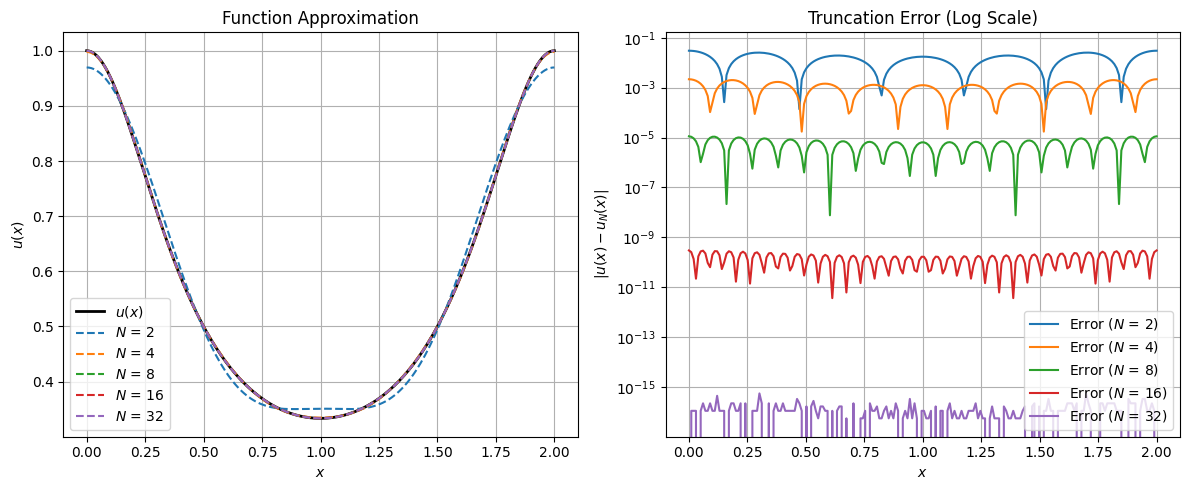

In [24]:
import matplotlib.pyplot as plt
import numpy as np

u = lambda x: 1 / (2 - np.cos(x * np.pi))

u_k = lambda k: 1 / (np.sqrt(3) * (2 + np.sqrt(3))**np.abs(k))

def u_N(x, N):
    approx = np.zeros_like(x, dtype=complex)
    
    for k in range(-N, N + 1):
        term = u_k(k) * np.exp(1j * k * np.pi * x)
        
        approx += term
    
    return np.real(approx)

x = np.linspace(0, 2, 200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(x, u(x), 'k-', linewidth=2, label='$u(x)$')
for N in [2, 4, 8, 16, 32]:
    ax1.plot(x, u_N(x, N), '--', label=f'$N$ = {N}')
ax1.set_title("Function Approximation")
ax1.set_xlabel("$x$")
ax1.set_ylabel("$u(x)$")
ax1.legend()
ax1.grid(True)

for N in [2, 4, 8, 16, 32]:
    error = np.abs(u(x) - u_N(x, N))
    ax2.plot(x, error, label=f'Error ($N$ = {N})')
ax2.set_title("Truncation Error (Log Scale)")
ax2.set_xlabel("$x$")
ax2.set_ylabel("$|u(x) - u_N(x)|$")
ax2.set_yscale('log')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### subpart b)

We recall the discrete fourier transform method;
$$
    \tilde{u}_k = \frac{1}{N} \sum_{j=0}^{N-1} u(x_j) e^{-i k \pi x_j}
$$
And plot for each $N$-value the absolute difference between $\hat{u}(x)$ and $\tilde{u}_k$

In [3]:
def u_discrete(k, N):
    j = np.arange(N)
    
    x_j = j * (2/N)
    
    return (1/N) * np.sum((u(x_j) * np.exp(-1j * k * np.pi * x_j)))

exact_coeff_k2 = u_k(2)
print(f"Exact Continuous Coefficient for k=2: {exact_coeff_k2:.6f}\n")

print("N  | Discrete Coeff | Error (Absolute Difference)")
print("-------------------------------------------------")

for N in [4, 8, 16, 32, 64]:
    approx_coeff = u_discrete(2, N)
    
    error = np.abs(exact_coeff_k2 - approx_coeff)
    
    print(f"{N:<2} | {np.real(approx_coeff):.6f}       | {error:.2e}")

Exact Continuous Coefficient for k=2: 0.041452

N  | Discrete Coeff | Error (Absolute Difference)
-------------------------------------------------
4  | 0.083333       | 4.19e-02
8  | 0.041667       | 2.15e-04
16 | 0.041452       | 5.71e-09
32 | 0.041452       | 4.14e-17
64 | 0.041452       | 4.22e-17


As we know from subpart a) the continuous Fourier coefficients $\hat{u}_k$ have exponential decay as the frequency $k$ increases. And due to aliasing on this grid from 0 to 2 of $N$ points, the discrete Fourier coefficient $\tilde{u}_k$ is not only equal to $\hat{u}_k$ but also the sum of every other high frequency aliases, $\hat{u}_{k+mN}$ for $m \in \mathbb{Z}$. This mechanism gives us that the lower the $N$ value, the higher the disturbance of the aliases are. As we see when $N=4$, the main contributor to noise is consequently $\hat{u}_{2 + 1 \cdot 4}$ which is way larger than for $N=16$, i.e. $\hat{u}_{2 + 1 \cdot 4} >> \hat{u}_{2 + 1 \cdot 16}$. So in conclusion, the aliasing error term vanishes exponentially such that the discrete coefficient converges to the exact continuous coefficient.

### subpart c)

We substitute our expression of $\tilde{u}_k$ into the expression for the Fourier interpolant (the discrete trigonometric polynomial) $I_k u(x)$. And since our range changed from $[0,2]$ to $[0,2\pi]$ the basis functions are changed from $e^{ik\pi x}$ to $e^{ikx}$;
\begin{align*}
    I_N u(x) &= \sum_{k=-N/2}^{N/2} \frac{\tilde{u}_k}{\bar{c}_k} e^{ikx}\\
    I_N u(x) &= \sum_{k=-N/2}^{N/2} \frac{\frac{1}{N} \sum_{j=0}^{N-1} u(x_j) e^{-i k \pi x_j}}{\bar{c}_k} e^{ikx}
\end{align*}
This does not look so good, so we rearrange things a bit. First we define $\theta = x - x_j$, and secondly we define second term of the equation as $h_j (\theta)$;
$$
    I_N u(x) = \sum_{j=0}^{N-1} u(x_j) \underbrace{\left( \frac{1}{N} \sum_{k=-N/2}^{N/2} \frac{1}{\bar{c}_k} e^{ik(\theta)} \right)}_{h_j(\theta)}
$$
By definition of $\bar{c}_k$ we write out boundary cases to get rid of $\bar{c}_k$ and rearrange by Euler's formula;
$$
    h_j(\theta) = \frac{1}{N} \cos\left(\frac{N}{2}\theta\right) \sum_{k=-N/2 + 1}^{N/2 - 1} e^{ik(\theta)}
$$
the last term is a finite geometric series and is written as
$$
    h_j(\theta) = \frac{1}{N} \cos\left(\frac{N}{2}\theta\right) \frac{e^{i\theta(-N/2 + 1)} - e^{i\theta(N/2)}}{1 - e^{i\theta}}
$$
which again by Euler's formula rewrites as
$$
    h_j(\theta) = \frac{1}{N} \cos\left(\frac{N}{2}\theta\right) \frac{ \sin\left( \frac{N}{2} \theta \right)\cos\left( \frac{1}{2} \theta \right) }{\sin\left( \frac{1}{2} \theta \right)}
$$
or more cleanly, with $x$ substituted back;
$$
    h_j (x) = \frac{1}{N} \sin\left( \frac{N}{2}(x - x_j) \right) \cot\left( \frac{1}{2}(x - x_j) \right)
$$
This is an expression for the Lagrange polynomials, so we plot this on a uniform grid as described with 6 nodal points, and see that $h_j(x_i) = \delta_{ij}$;

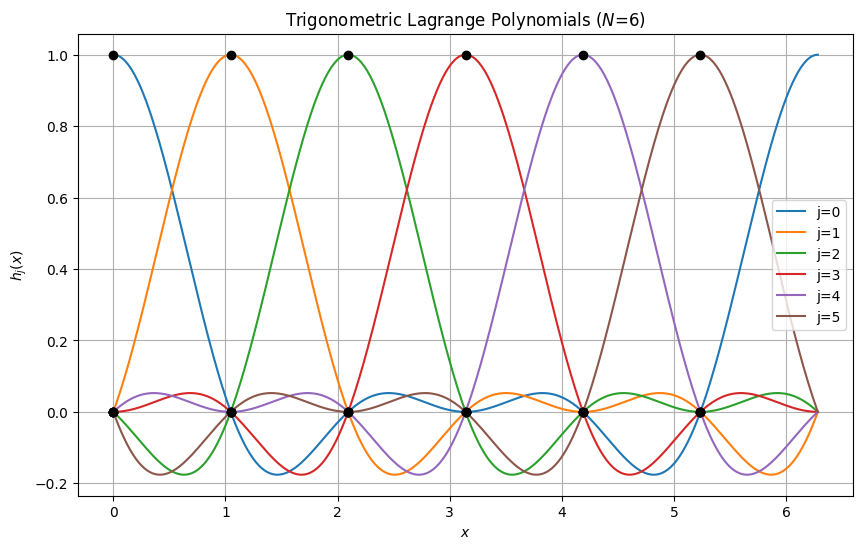

In [32]:
import numpy as np
import matplotlib.pyplot as plt

N = 6
x = np.linspace(0, 2*np.pi, 500)
x_nodes = np.arange(N) * (2*np.pi / N)

plt.figure(figsize=(10, 6))
for j in range(N):
    diff = x - x_nodes[j]
    h_j = np.zeros_like(x)
    
    mask = np.abs(np.sin(0.5 * diff)) > 1e-10
    h_j[mask] = (1/N) * (np.cos((N/2) * diff[mask]) + np.sin(((N-1)/2) * diff[mask]) / np.sin((1/2) * diff[mask]))
    h_j[~mask] = 1.0
    
    plt.plot(x, h_j, label=f'j={j}')
    plt.plot(x_nodes, np.where(np.arange(N)==j, 1, 0), 'ko')

plt.title(f"Trigonometric Lagrange Polynomials ($N$={N})")
plt.xlabel("$x$")
plt.ylabel("$h_j(x)$")
plt.legend()
plt.grid(True)
plt.show()

The differentiation matrix $\mathcal{D}$ is given as the matrix with the slope $h_j '(x_i)$ for element $i,j$. If those are equal, $i = j$, then the Lagrange polynomial is at a maximum and thus, the slope is $0$. For the off-diagonal elements in the matrix, where $i \neq j$, the slope is given by $h_j ' (x_i)$ where we know the distance between the nodes is given as $\frac{2\pi}{N}(i - j)$. In this case we can write the differentiation of $h_j (x)$ as
$$
    h_j '(x_i) = \frac{1}{2} (-1)^{(i - j)} \cot \left( \frac{1}{2} (x_i - x_j) \right)
$$
We define the differentiation matrix in the Python function

In [37]:
def fourier_diff_matrix(N):
    x = np.arange(N) * ((2*np.pi)/N)
    
    D = np.zeros((N,N))
    
    for i in range(N):
        for j in range(N):
            if i != j:
                diff = x[i] - x[j]
                
                term1 = -(N/2) * np.sin((N/2) * diff)
                term2_num = ((N-1)/2) * np.cos(((N-1)/2) * diff) * np.sin(diff/2) - (1/2) * np.sin(((N-1)/2) * diff) * np.cos(diff/2)
                term2_den = np.sin(diff/2)**2
                
                D[i,j] = (1/N) * (term1 + (term2_num / term2_den))
            else:
                D[i,j] = 0
                
    return D

### subpart d)

Since the domain shifted from $[0,2\pi]$ to $[0,2]$ we need to redefine our physical distance measure. So we say if $\theta \in [0,2\pi]$ and $x \in [0,2]$, then $x = c\theta$ for some constant $c$. This constant is $c = \frac{1}{\pi}$ such that for the upper boundary we get $x = \frac{1}{\pi}(2\pi) = 2$ for $\theta = 2 \pi$. Thus, $x = \frac{1}{\pi}\theta$ or $\theta = \pi x$.\
And because $\mathcal{D}$ is our differentiation matrix for the domain $\theta$, applying it for a vector $v$ gives $\mathcal{D}v = \frac{dv}{d\theta}$. But we want to compute $\frac{dv}{dx}$ for the new domain $x$, so we arrange this as $\frac{dv}{dx} = \frac{dv}{d\theta} \frac{d\theta}{dx}$ where $\frac{d\theta}{dx} = \pi$ for $\theta = \pi x$. Thereby giving us $\frac{dv}{dx} = \mathcal{D}v \cdot \pi$. We compute this for different values of $N$, and measure the errors; 

In [39]:
N_vals = [4,8,16,32,64]

for N in N_vals:
    D = fourier_diff_matrix(N)
    x = np.arange(N) * (2/N)
    v = np.exp(np.sin(np.pi * x))
    v_num_prime = np.pi * D @ v
    v_exact_prime = np.pi * np.cos(np.pi * x) * np.exp(np.sin(np.pi * x))
    
    max_error = np.max(np.abs(v_num_prime - v_exact_prime))
    
    print(f"N = {N} | max error: {max_error:.2e}")

N = 4 | max error: 5.50e-01
N = 8 | max error: 1.36e-02
N = 16 | max error: 5.54e-07
N = 32 | max error: 1.72e-13
N = 64 | max error: 5.85e-13


We see that as $N$ increases the error term drops exponentially. This is what we call spectral convergence.

### subpart e)

We start by constructing the functions $w^1(x)$, $w^2(x)$, and $w^3(x)$. Since $w^i(x) = \frac{dw^{i + 1}}{dx}$ we also have that $w^{i+1}(x) = \int w^i (x) dx$, so the functions are constructed by sequentially integrating the base function $w^0(x)$. For $w^1(x)$ we get
$$
    w^1(x) = 
    \begin{cases}
        - \frac{\sin(\pi x)}{\pi} + c_1 &\text{for} &-2 \leq x < 0\\
        \frac{\sin(\pi x)}{\pi} + c_2 &\text{for} &0 \leq x \leq 2
    \end{cases}
$$
It is stated that $w^{i+1} \in C^i([-2,2])$ such that $w^1(x) \in C^0([-2,2])$, meaning the function should be a continuous function. To ensure this, we must make sure that both limits meet eachother at $x=0$. And as both limits are equal, $\frac{\sin(\pi \cdot 0)}{\pi} = - \frac{\sin(\pi \cdot 0)}{\pi} = 0$, we do not need to adjust $c_1$ and $c_2$, we say $c_1 = c_2 = 0$. We continue this pattern for $w^2(x)$, and $w^3(x)$ and get
$$
    w^2(x) = 
    \begin{cases}
        \frac{\cos(\pi x)}{\pi^2} - \frac{1}{\pi^2} &\text{for} &-2 \leq x < 0\\
        - \frac{\cos(\pi x)}{\pi^2} + \frac{1}{\pi^2} &\text{for} &0 \leq x \leq 2
    \end{cases}
$$
$$
    w^3(x) = 
    \begin{cases}
        \frac{\sin(\pi x)}{\pi^3} - \frac{x}{\pi^2} &\text{for} &-2 \leq x < 0\\
        - \frac{\sin(\pi x)}{\pi^3} + \frac{x}{\pi^2} &\text{for} &0 \leq x \leq 2
    \end{cases}
$$
To compute the discrete derivative of these functions, we again need to scale our differentiation matrix $\mathcal{D}$. We use same methodology as in subpart d) to find a scaling factor of $\frac{\pi}{2}$, such that the discrete derivative is computed as $\frac{\pi}{2} \mathcal{D} w^i$. We measure the $L^2$-norm of the error for each of these functions using the given definition of the $L^2$-norm. But since this definition is continuous, and we want discrete $L^2$-norms, we replace the integral with a Riemann sum rectangle approach such that the discrete $L^2$-norm definition becomes $\sqrt{\sum u(x)^2 \Delta x}$, where $\Delta x$ is the stepping size for $N$, and $u(x)$ is our error function. Since it is stated that $w^i(x) = \frac{dw^{i+1}}{dx}$, the theoretical derivative of the function $w^i(x)$ is therefore just the previous function $w^{i-1}(x)$. Therefore our error function is simply just the difference between the theoretical derivative and the numerical differentiation matrix product.\
Lastly, we expect the convergence rate of our functions will increase as $i$ does, i.e. $w^3(x)$ has faster convergence than $w^2(x)$ &c.

N = 4 | w1 : 2.00e+00 | w2 : 4.50e-01 | w3 : 6.15e-02
N = 8 | w1 : 1.29e+00 | w2 : 1.37e-01 | w3 : 1.13e-02
N = 16 | w1 : 8.97e-01 | w2 : 4.73e-02 | w3 : 2.09e-03
N = 32 | w1 : 6.32e-01 | w2 : 1.66e-02 | w3 : 3.76e-04
N = 64 | w1 : 4.46e-01 | w2 : 5.87e-03 | w3 : 6.68e-05


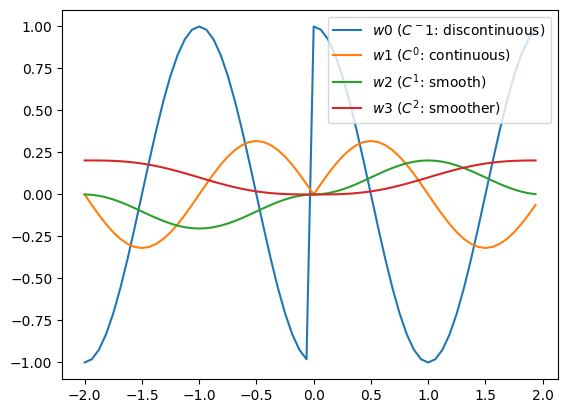

In [18]:
N_vals = [4,8,16,32,64]

for N in N_vals:
    x = (np.arange(N) * (4/N)) - 2
    
    D = fourier_diff_matrix(N)
    
    w0 = np.where(x < 0, -np.cos(np.pi*x), np.cos(np.pi*x))
    w1 = np.where(x < 0, -np.sin(np.pi*x)/np.pi, np.sin(np.pi*x)/np.pi)
    w2 = np.where(x < 0, np.cos(np.pi*x)/np.pi**2 - 1/np.pi**2, -np.cos(np.pi*x)/np.pi**2 + 1/np.pi**2)
    w3 = np.where(x < 0, np.sin(np.pi*x)/np.pi**3 - x/np.pi**2, -np.sin(np.pi*x)/np.pi**3 + x/np.pi**2)
    
    w1dx = (np.pi/2) * D @ w1
    w1err = w0 - w1dx
    w1_L2_err = np.sqrt(np.sum(w1err**2) * (4/N))
    
    w2dx = (np.pi/2) * D @ w2
    w2err = w1 - w2dx
    w2_L2_err = np.sqrt(np.sum(w2err**2) * (4/N))
    
    w3dx = (np.pi/2) * D @ w3
    w3err = w2 - w3dx
    w3_L2_err = np.sqrt(np.sum(w3err**2) * (4/N))
    
    print(f"N = {N} | w1 : {w1_L2_err:.2e} | w2 : {w2_L2_err:.2e} | w3 : {w3_L2_err:.2e}")
    
plt.plot(x, w0, label="$w0$ ($C^-1$: discontinuous)")
plt.plot(x, w1, label="$w1$ ($C^0$: continuous)")
plt.plot(x, w2, label="$w2$ ($C^1$: smooth)")
plt.plot(x, w3, label="$w3$ ($C^2$: smoother)")
plt.legend()
plt.show()

### subpart f)

We recall that FFT represents a smooth function $v$ as the finite sum of exponential waves on the form $e^{ik\theta}$ multiplied by some coefficient $\hat{v}_k$, but this is just some constant. So the derivative of these wrt $\theta$ are then the derivative of the exponential wave is $ik \cdot e^{ik\theta}$, where $k$ is the frequency. Thus, we compute the FFT to isolate $\hat{v}_k$, and multiply all these coefficients by $ik$, and then we apply the inverse FFTto reconstruct it. We also remember to scale the $x \in [0,2]$ domain to our $\theta$ domain with the scaling factor $\pi$. For $N$ ranging from $32$ to $8\_192$ we measure the compute time for both FFT and our differentiation matrix.

<>:32: SyntaxWarning: invalid escape sequence '\l'
<>:32: SyntaxWarning: invalid escape sequence '\l'
/var/folders/s0/2b2p_vwn3gj_82fk6cgm4nfr0000gn/T/ipykernel_82912/915653255.py:32: SyntaxWarning: invalid escape sequence '\l'
  plt.loglog(N_vals, time_fft, 's-', label="FFT $O(N \log N)$")


32 | 0.000161 | 0.000877
64 | 0.000036 | 0.000532
128 | 0.000027 | 0.000131
256 | 0.000042 | 0.000090
512 | 0.000246 | 0.000101
1024 | 0.000325 | 0.000132
2048 | 0.003012 | 0.000193
4096 | 0.036331 | 0.001235
8192 | 0.145855 | 0.001829


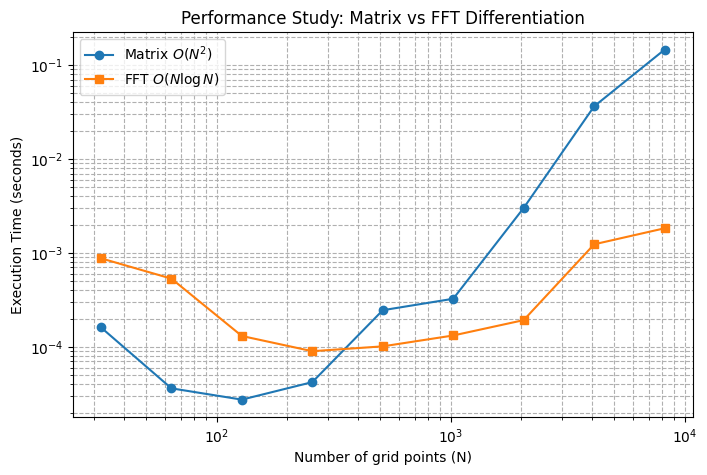

In [21]:
import scipy as sc
import time

N_vals = [2**i for i in range(5, 14)]
time_matrix = []
time_fft = []

for N in N_vals:
    x = np.arange(N) * (2/N)
    v = np.exp(np.sin(np.pi * x))
    D = fourier_diff_matrix(N)
    
    # matrix
    t0 = time.perf_counter()
    v_num_matrix = np.pi * (D @ v)
    t1 = time.perf_counter()
    time_matrix.append(t1 - t0)
    
    # fft
    t0 = time.perf_counter()
    v_hat = sc.fft.fft(v)
    k = sc.fft.fftfreq(N) * N
    v_hat_deriv = v_hat * (1j * k) * np.pi
    v_num_fft = np.real(sc.fft.ifft(v_hat_deriv))
    t1 = time.perf_counter()
    time_fft.append(t1 - t0)
    
    print(f"{N} | {time_matrix[-1]:.6f} | {time_fft[-1]:.6f}")
    
plt.figure(figsize=(8, 5))
plt.loglog(N_vals, time_matrix, 'o-', label="Matrix $O(N^2)$")
plt.loglog(N_vals, time_fft, 's-', label="FFT $O(N \log N)$")
plt.xlabel("Number of grid points (N)")
plt.ylabel("Execution Time (seconds)")
plt.title("Performance Study: Matrix vs FFT Differentiation")
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()


We see a breakpoint between $N = 256$ and $N = 512$ depending on the independent run, where FFT begins to outperform the differentiation matrix. We reason that the differentiation matrix operation, essentially multiplying a $N \times N$ matrix by a vector of length $N$, has expected $O(N^2)$. FFT achieves $O(N log N)$. Thereby confirming that for $N \rightarrow \infty$ FFT outperforms differentiation matrix multiplication by a huge margin, and for very large $N$, FFT is the only feasible method.

## Polynomial Methods (Estimated effort: 2 weeks)
This part comes with Matlab scripts for computing the Jacobi-Gauss-Lobatto nodes (JacobiGL.m)
and Jacobi quadrature rules (JacobiGQ.m). Two additional Matlab scripts for evaluating Jacobi
Polynomials (JacobiP.m) and the first derivative hereof (GradJacobiP.m) will be needed.
### subpart h)
$\beta$

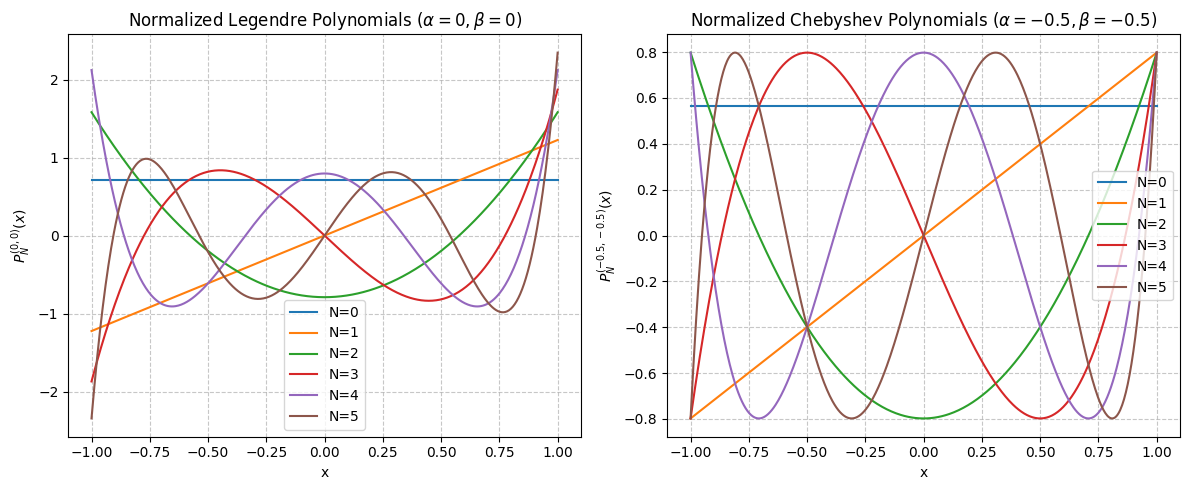

In [49]:
from scipy.special import gamma
  
def jacobi_P(x, alpha, beta, N):
    x = np.atleast_1d(x)
    
    P_prev = np.zeros_like(x, dtype=float)
    
    P_curr = np.sqrt(gamma(alpha + beta + 2) / ((2**(alpha + beta + 1)) * gamma(alpha + 1) * gamma(beta + 1))) * np.ones_like(x)
    
    if N == 0:
        return P_curr
    
    b_prev = 0.0
    
    for n in range(N):
        h_n = 2 * n + alpha + beta
        
        if abs(alpha + beta) < 1e-14 and n == 0:
            a_n = 0.0
        else:
            a_n = -(alpha**2 - beta**2) / (2 * h_n * (h_n + 2))
            
        if abs(alpha + beta + 1) < 1e-14 and n == 0:
            b_n = np.sqrt(2 * (1 + alpha) * (1 + beta))
        else:
            b_n = 2 / (h_n + 2) * np.sqrt(((n+1) * ((n+1) + alpha + beta) * ((n+1) + alpha) * ((n+1) + beta)) / ((h_n + 1) * (h_n + 3)))
        
        if n == 0:
            P_next = ((x - a_n) * P_curr) / b_n
        else:
            P_next = ((x - a_n) * P_curr - b_prev * P_prev) / b_n
            
        P_prev = P_curr
        P_curr = P_next
        b_prev = b_n
        
    return P_curr

x = np.linspace(-1, 1, 500)
degrees = [0, 1, 2, 3, 4, 5]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Legendre Polynomials (alpha=0, beta=0)
for N in degrees:
    y_leg = jacobi_P(x, alpha=0.0, beta=0.0, N=N)
    ax1.plot(x, y_leg, label=f'N={N}')

ax1.set_title(r'Normalized Legendre Polynomials ($\alpha=0, \beta=0$)')
ax1.set_xlabel('x')
ax1.set_ylabel(r'$P_N^{(0,0)}(x)$')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# Chebyshev Polynomials (alpha=-0.5, beta=-0.5)
for N in degrees:
    y_cheb = jacobi_P(x, alpha=-0.5, beta=-0.5, N=N)
    ax2.plot(x, y_cheb, label=f'N={N}')

ax2.set_title(r'Normalized Chebyshev Polynomials ($\alpha=-0.5, \beta=-0.5$)')
ax2.set_xlabel('x')
ax2.set_ylabel(r'$P_N^{(-0.5,-0.5)}(x)$')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()

### subpart i)

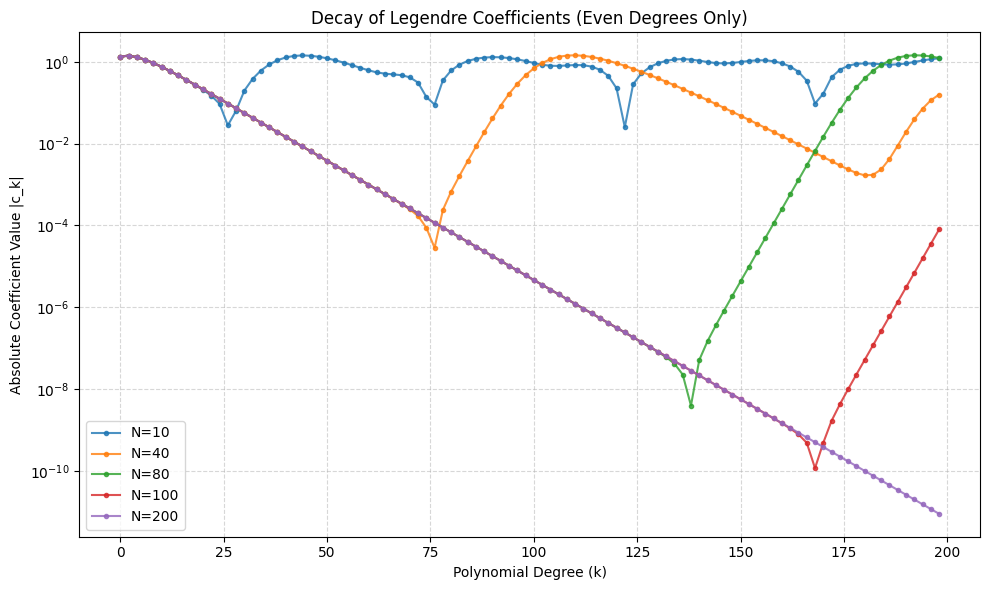

In [57]:
import scipy
from scipy.special import gamma

def jacobi_GQ(alpha, beta, N):
    if N == 0:
        x = np.array([-(alpha-beta)/(alpha+beta+2)])
        w = np.array([2.0])
        return x, w
    
    n = np.arange(N+1)
    h_n = 2 * n + alpha + beta
    
    diag = np.zeros(N+1)
    valid = (h_n != 0) & (h_n + 2 != 0)
    diag[valid] = -(alpha**2 - beta**2) / (2 * h_n[valid] * (h_n[valid] + 2))
    
    n_super = np.arange(1, N + 1)
    h_n_super = 2 * n_super + alpha + beta
    
    superdiag = 2 / (h_n_super + 2) * np.sqrt(
        (n_super * (n_super + alpha + beta) * (n_super + alpha) * (n_super + beta)) /
        ((h_n_super + 1) * (h_n_super + 3))
    )
    
    J = np.diag(diag) + np.diag(superdiag, k=1) + np.diag(superdiag, k=-1)
    
    x, V = scipy.linalg.eigh(J)
    
    w = (V[0,:]**2) * (2**(alpha+beta+1) / (alpha+beta+1)) * (gamma(beta+1) / gamma(alpha+beta+1))
    
    return x, w

N_vals = [10, 40, 80, 100, 200]
u = lambda x: 1 / (2 - np.cos(np.pi * x))

results = {}

for N in N_vals:
    x, w = jacobi_GQ(alpha=0.0, beta=0.0, N=N-1)
    u_val = u(x)
    coefficients = np.zeros(200)
    for k in range(200):
        P_k = jacobi_P(x, alpha=0.0, beta=0.0, N=k)
        c_k = np.sum(u_val * P_k * w)
        coefficients[k] = c_k
    
    results[N] = np.abs(coefficients)

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# Create an array of just the even degrees: 0, 2, 4, ..., 198
even_k = np.arange(0, 200, 2)

for N in N_vals:
    # results[N][::2] takes every second element, matching the even degrees
    plt.semilogy(even_k, results[N][::2], '.-', label=f'N={N}', alpha=0.8)

plt.title("Decay of Legendre Coefficients (Even Degrees Only)")
plt.xlabel("Polynomial Degree (k)")
plt.ylabel("Absolute Coefficient Value |c_k|")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

### subpart j)

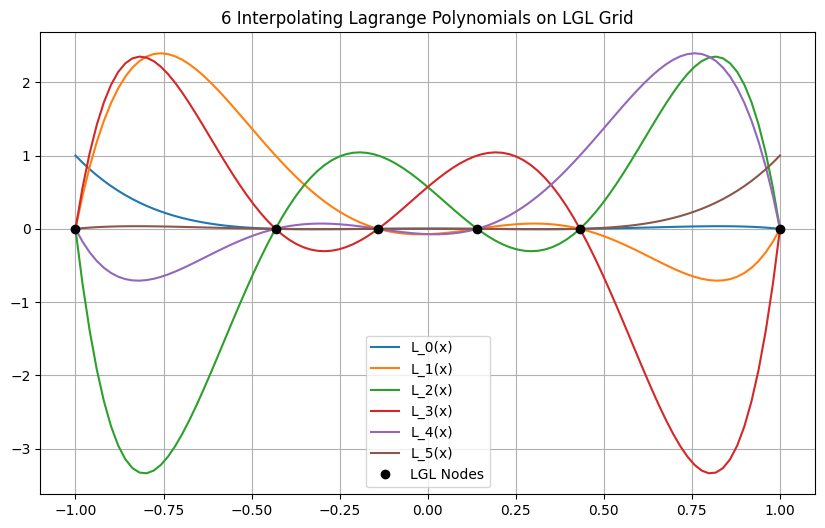

In [102]:
x_internal, _ = jacobi_GQ(alpha=1.0, beta=1.0, N=3)
x_lgl = np.concatenate(([-1.0], x_internal, [1.0]))

N = len(x_lgl)
V = np.zeros((N, N))

for i in range(N):
    V[:,i] = jacobi_P(x_lgl, alpha=0.0, beta=0.0, N=i)
    
V_inv = np.linalg.inv(V)

x_dense = np.linspace(-1, 1, 100)
V_dense = np.zeros((100, N))

for j in range(N):
    V_dense[:,j] = jacobi_P(x_dense, alpha=0.0, beta=0.0, N=j)
    
lagrange_dense = V_dense @ V_inv

plt.figure(figsize=(10, 6))
for k in range(N):
    plt.plot(x_dense, lagrange_dense[:, k], label=f'L_{k}(x)')

plt.plot(x_lgl, np.zeros(N), 'ko', label='LGL Nodes')
plt.grid(True)
plt.title("6 Interpolating Lagrange Polynomials on LGL Grid")
plt.legend()
plt.show()

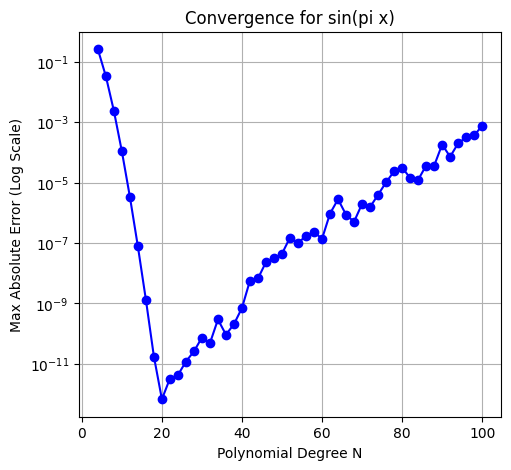

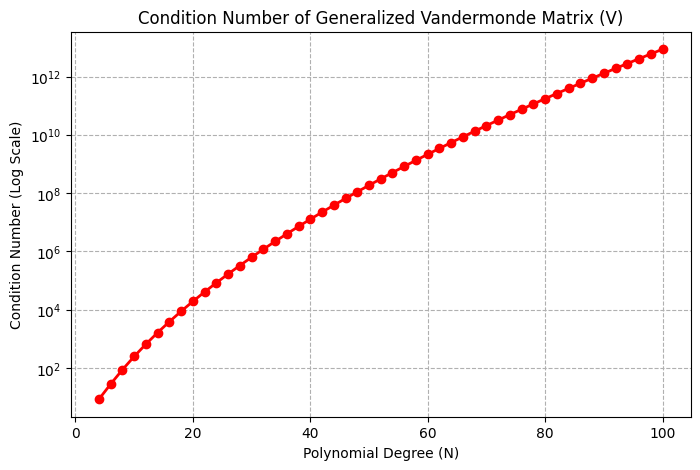

In [99]:
v = lambda x: np.sin(np.pi * x)

v_sparse = v(x_lgl)

v_coeffs = V_inv @ v_sparse

v_approx_dense = V_dense @ v_coeffs

N_vals = [2+i for i in range(2,100,2)]
errors = []
cond_numbers = []

x_dense = np.linspace(-1, 1, 100)
v_exact_dense = np.sin(np.pi * x_dense)

for N in N_vals:
    x_internal, _ = jacobi_GQ(alpha=1.0, beta=1.0, N=N-2)
    x_lgl = np.concatenate(([-1.0], x_internal, [1.0]))
    
    N_nodes = len(x_lgl)
    V = np.zeros((N_nodes, N_nodes))
    for i in range(N_nodes):
        V[:,i] = jacobi_P(x_lgl, alpha=0.0, beta=0.0, N=i)
    cond_V = np.linalg.cond(V)
    cond_numbers.append(cond_V)
    
    V_dense = np.zeros((100, N_nodes))
    for j in range(N_nodes):
        V_dense[:,j] = jacobi_P(x_dense, alpha=0.0, beta=0.0, N=j)
        
    V_inv = np.linalg.inv(V)
    v_sparse = np.sin(np.pi * x_lgl)
    v_coeffs = V_inv @ v_sparse
    v_approx = V_dense @ v_coeffs
    
    max_error = np.max(np.abs(v_exact_dense - v_approx))
    errors.append(max_error)
    
# Plot Convergence
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.semilogy(N_vals, errors, 'bo-')
plt.title("Convergence for sin(pi x)")
plt.xlabel("Polynomial Degree N")
plt.ylabel("Max Absolute Error (Log Scale)")
plt.grid(True)

plt.figure(figsize=(8, 5))
plt.semilogy(N_vals, cond_numbers, 'ro-', linewidth=2)
plt.title("Condition Number of Generalized Vandermonde Matrix (V)")
plt.xlabel("Polynomial Degree (N)")
plt.ylabel("Condition Number (Log Scale)")
plt.grid(True, which="both", ls="--")
plt.show()

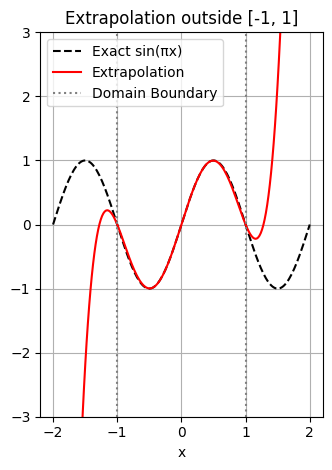

In [104]:
x_internal, _ = jacobi_GQ(alpha=1.0, beta=1.0, N=3)
x_lgl = np.concatenate(([-1.0], x_internal, [1.0]))

v = lambda x: np.sin(np.pi * x)

N = len(x_lgl)
V = np.zeros((N, N))

for i in range(N):
    V[:, i] = jacobi_P(x_lgl, alpha=0.0, beta=0.0, N=i)

V_inv = np.linalg.inv(V)

v_sparse = v(x_lgl)

v_coeffs = V_inv @ v_sparse

x_extended = np.linspace(-2, 2, 200)

V_extended_dense = np.zeros((len(x_extended), 6))
for i in range(6):
    V_extended_dense[:,i] = jacobi_P(x_extended, alpha=0.0, beta=0.0, N=i)
    
v_approx_extended = V_extended_dense @ v_coeffs
v_exact_extended = np.sin(np. pi * x_extended)

plt.subplot(1, 2, 2)
plt.plot(x_extended, v_exact_extended, 'k--', label="Exact sin(πx)")
plt.plot(x_extended, v_approx_extended, 'r-', label="Extrapolation")
plt.axvline(-1, color='gray', linestyle=':', label="Domain Boundary")
plt.axvline(1, color='gray', linestyle=':')
plt.ylim(-3, 3)
plt.title("Extrapolation outside [-1, 1]")
plt.xlabel("x")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### subpart k)

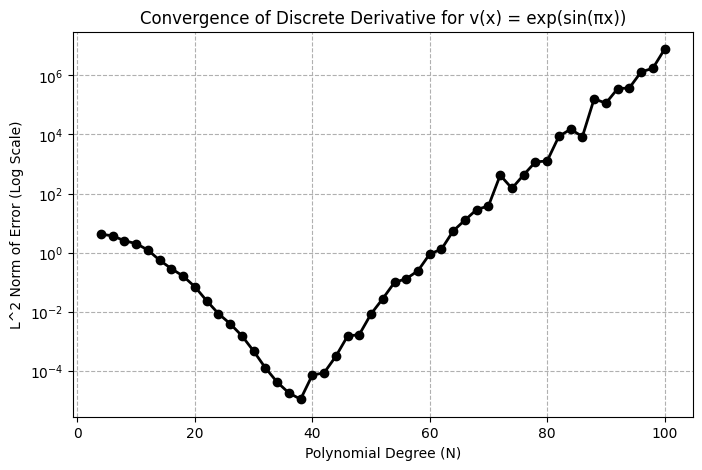

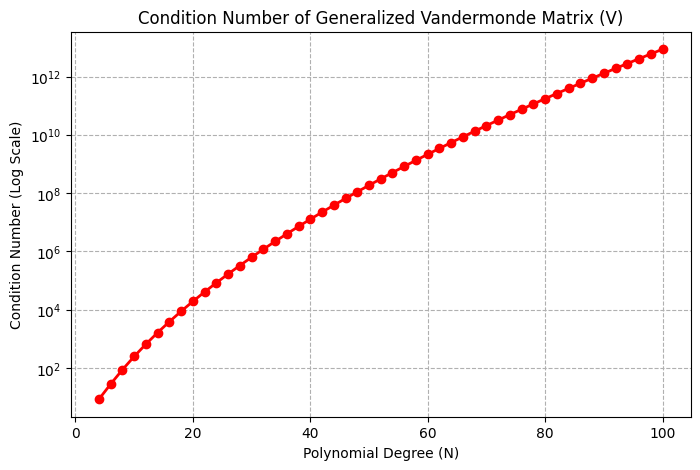

In [101]:
def grad_jacobi_P(x, alpha, beta, N):
    if N == 0:
        return np.zeros_like(x)
    else:
        return np.sqrt(N * (N + alpha + beta + 1.0)) * jacobi_P(x, alpha + 1.0, beta + 1.0, N - 1)

v = lambda x: np.exp(np.sin(np.pi * x))

v_deriv = lambda x: np.pi * np.cos(np.pi * x) * np.exp(np.sin(np.pi * x))

N_vals = [2+i for i in range(2, 100,2)]
L2_errors = []
cond_numbers = []

for N in N_vals:
    r_internal, _ = jacobi_GQ(alpha=1.0, beta=1.0, N=N-2)
    r_lgl = np.concatenate(([-1.0], r_internal, [1.0]))
    N_nodes = len(r_lgl)
    
    x_lgl = r_lgl + 1
    
    V = np.zeros((N_nodes, N_nodes))
    V_x = np.zeros((N_nodes, N_nodes))
    
    for i in range(N_nodes):
        V[:,i] = jacobi_P(r_lgl, alpha=0.0, beta=0.0, N=i)
        V_x[:,i] = grad_jacobi_P(r_lgl, alpha=0.0, beta=0.0, N=i)
        
    cond_V = np.linalg.cond(V)
    cond_numbers.append(cond_V)
    
    V_inv = np.linalg.inv(V)
    D = V_x @ V_inv
    
    v_nodes = v(x_lgl)
    v_deriv_approx = D @ v_nodes
    
    v_deriv_true = v_deriv(x_lgl)
    error_nodal = v_deriv_approx - v_deriv_true
    
    error_coeffs = V_inv @ error_nodal
    L2_error = np.sqrt(np.sum(error_coeffs**2))
    L2_errors.append(L2_error)
    
# Plot Convergence
plt.figure(figsize=(8, 5))
plt.semilogy(N_vals, L2_errors, 'ko-', linewidth=2)
plt.title("Convergence of Discrete Derivative for v(x) = exp(sin(πx))")
plt.xlabel("Polynomial Degree (N)")
plt.ylabel("L^2 Norm of Error (Log Scale)")
plt.grid(True, which="both", ls="--")
plt.show()


plt.figure(figsize=(8, 5))
plt.semilogy(N_vals, cond_numbers, 'ro-', linewidth=2)
plt.title("Condition Number of Generalized Vandermonde Matrix (V)")
plt.xlabel("Polynomial Degree (N)")
plt.ylabel("Condition Number (Log Scale)")
plt.grid(True, which="both", ls="--")
plt.show()

### subpart l)

In [120]:
# rng = np.random.default_rng()
# while True:
#     a, b = rng.integers(low=-10, high=11, size=2)
#     if (a < b):
#         break
# print(f"Testing on random interval x in [{a}, {b}]")

a, b = 0.0, 2.0

J = (b - a) / 2.0
N = 6
r_internal, _ = jacobi_GQ(alpha=1.0, beta=1.0, N=N-2)
r_lgl = np.concatenate(([-1.0], r_internal, [1.0]))
N_nodes = len(r_lgl)

V = np.zeros((N_nodes, N_nodes))
for i in range(N_nodes):
    V[:, i] = jacobi_P(r_lgl, alpha=0.0, beta=0.0, N=i)

M_ref = np.linalg.inv(V @ V.T)
M_phys = J * M_ref

x_lgl = J * r_lgl + (b + a) / 2.0

u1 = 0.5 * np.ones_like(x_lgl)
u2 = 2 * np.sin(np.pi * x_lgl)

L2_u1 = np.sqrt(u1.T @ M_phys @ u1)
L2_u2 = np.sqrt(u2.T @ M_phys @ u2)

analytical_u1 = 0.5 * np.sqrt(b - a)

integral_u2_b = 2*b - np.sin(2*np.pi*b)/np.pi
integral_u2_a = 2*a - np.sin(2*np.pi*a)/np.pi
analytical_u2 = np.sqrt(integral_u2_b - integral_u2_a)

print(f"Discrete L2 of u1=0.5:       {L2_u1:.8f} (Analytical: {analytical_u1:.8f})")
print(f"Discrete L2 of u2=2sin(pix): {L2_u2:.8f} (Analytical: {analytical_u2:.8f})")

Discrete L2 of u1=0.5:       0.70710678 (Analytical: 0.70710678)
Discrete L2 of u2=2sin(pix): 1.98305011 (Analytical: 2.00000000)
